## Laboratorio 07 - Problema de CartPole con Deep Q-Learning 

In [40]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

### Creación de Entorno CartPole

In [41]:
env = gym.make('CartPole-v1')

print("¡Entorno CartPole creado exitosamente!\n")
print(f"Espacio de observación: {env.observation_space}")
print(f"Espacio de acción: {env.action_space}")
print(f"Número de acciones posibles: {env.action_space.n}")

state, info = env.reset()
print(f"Dimensiones del estado: {env.observation_space.shape}")
print(f"Estado inicial de ejemplo: {state}")

¡Entorno CartPole creado exitosamente!

Espacio de observación: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Espacio de acción: Discrete(2)
Número de acciones posibles: 2
Dimensiones del estado: (4,)
Estado inicial de ejemplo: [ 0.03065972  0.04565066 -0.04700334  0.03906766]


### Definición de las redes en línea y de destino

In [42]:
class DQN(nn.Module):
    """Red neuronal para Deep Q-Learning"""
    def __init__(self, state_size=4, action_size=2):
        super(DQN, self).__init__()
        
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 64) 
        self.fc3 = nn.Linear(64, action_size)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [43]:
# Creación de 2 redes neuronales
online_net = DQN(state_size=4, action_size=2)  # Red en línea para selección de acciones
target_net = DQN(state_size=4, action_size=2)  # Red de destino para estimación de valores Q

In [44]:
# Red destino con mismos pesos que la red en línea (Solo inicialmente)
target_net.load_state_dict(online_net.state_dict())

<All keys matched successfully>

In [45]:
print("Redes neuronales creadas exitosamente!")
print(f"Red en línea: {online_net}")
print(f"Red de destino: {target_net}")
print("La red de destino ha sido inicializada con los mismos pesos que la red en línea.")

Redes neuronales creadas exitosamente!
Red en línea: DQN(
  (fc1): Linear(in_features=4, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)
Red de destino: DQN(
  (fc1): Linear(in_features=4, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)
La red de destino ha sido inicializada con los mismos pesos que la red en línea.


### Establecer Hiperparámetros

In [ ]:
# Para el entrenamiento
NUM_EPISODES = 500
BATCH_SIZE = 64

# Factor de descuento
GAMMA = 0.99

# Parámetros de exploración (epsilon-greedy)
EPSILON = 1.0
EPSILON_DECAY = 0.995
EPSILON_MIN = 0.01

# Adicionales para optimización
LEARNING_RATE = 0.001
MEMORY_SIZE = 10000
TARGET_UPDATE_FREQ = 10

### Selección de acciones ε-greedy

In [47]:
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
online_net.to(device)
target_net.to(device)

def select_action_epsilon_greedy(state: np.ndarray, epsilon: float) -> int:
    """
    Política ε-greedy sobre la red en línea.
    - Con prob. ε: explora (acción aleatoria)
    - Con prob. 1-ε: explota (argmax Q(s,·))
    """
    if random.random() < epsilon:
        return env.action_space.sample()
    with torch.no_grad():
        s = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        q_values = online_net(s)
        return int(torch.argmax(q_values, dim=1).item())


### Reproducción de la experiencia (Experience Replay)

In [48]:
from collections import deque, namedtuple

Transition = namedtuple("Transition", ("state", "action", "reward", "next_state", "done"))

class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)
    def __len__(self):
        return len(self.buffer)
    def push(self, state, action, reward, next_state, done):
        self.buffer.append(Transition(state, action, reward, next_state, done))
    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        # Empaquetar en tensores en el dispositivo
        states      = torch.as_tensor(np.array([b.state for b in batch], dtype=np.float32), device=device)
        actions     = torch.as_tensor([b.action for b in batch], dtype=torch.long,  device=device).unsqueeze(1)
        rewards     = torch.as_tensor([b.reward for b in batch], dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.as_tensor(np.array([b.next_state for b in batch], dtype=np.float32), device=device)
        dones       = torch.as_tensor([b.done for b in batch], dtype=torch.float32, device=device).unsqueeze(1)
        return states, actions, rewards, next_states, dones

memory = ReplayBuffer(MEMORY_SIZE)


### Ciclo de entrenamiento (con actualización periódica de la red de destino)

In [49]:
optimizer = torch.optim.Adam(online_net.parameters(), lr=LEARNING_RATE)
loss_fn   = nn.SmoothL1Loss()  

def optimize_from_replay():
    """
    Toma un minibatch del buffer y hace un paso de optimización de DQN.
    """
    if len(memory) < BATCH_SIZE:
        return None 

    states, actions, rewards, next_states, dones = memory.sample(BATCH_SIZE)

    q_sa = online_net(states).gather(1, actions)

    with torch.no_grad():
        max_next_q = target_net(next_states).max(dim=1, keepdim=True)[0]
        targets = rewards + GAMMA * (1.0 - dones) * max_next_q

    loss = loss_fn(q_sa, targets)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(online_net.parameters(), 1.0) 
    optimizer.step()

    return float(loss.item())

epsilon = EPSILON
episode_rewards = []
episode_losses  = []

for ep in range(1, NUM_EPISODES + 1):
    state, _ = env.reset()
    ep_reward = 0.0
    ep_losses = []

    done = False
    while not done:
        # 1) Selección de acción ε-greedy
        action = select_action_epsilon_greedy(state, epsilon)

        # 2) Interacción con el entorno
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # 3) Guardar transición en el buffer
        memory.push(state, action, reward, next_state, float(done))

        # 4) Actualizar red en línea a partir del replay buffer
        loss_val = optimize_from_replay()
        if loss_val is not None:
            ep_losses.append(loss_val)

        # 5) Avanzar estado/acumular recompensa
        state = next_state
        ep_reward += reward

    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    if ep % TARGET_UPDATE_FREQ == 0:
        target_net.load_state_dict(online_net.state_dict())

    episode_rewards.append(ep_reward)
    episode_losses.append(np.mean(ep_losses) if ep_losses else np.nan)

    if ep % 10 == 0:
        avg10 = np.mean(episode_rewards[-10:])
        print(f"Ep {ep:04d} | Recompensa: {ep_reward:6.1f} | Prom(últ.10): {avg10:6.1f} | "
              f"ε={epsilon:0.3f} | Memoria={len(memory)} | Loss={np.nanmean(episode_losses[-10:]):.4f}")

print("\n✓ Entrenamiento completado!")

Ep 0010 | Recompensa:   13.0 | Prom(últ.10):   21.8 | ε=0.951 | Memoria=218 | Loss=0.0894
Ep 0020 | Recompensa:   17.0 | Prom(últ.10):   24.0 | ε=0.905 | Memoria=458 | Loss=0.0487
Ep 0030 | Recompensa:   57.0 | Prom(últ.10):   23.1 | ε=0.860 | Memoria=689 | Loss=0.0801
Ep 0040 | Recompensa:   14.0 | Prom(últ.10):   27.3 | ε=0.818 | Memoria=962 | Loss=0.0862
Ep 0050 | Recompensa:   26.0 | Prom(últ.10):   21.9 | ε=0.778 | Memoria=1181 | Loss=0.1150
Ep 0060 | Recompensa:   31.0 | Prom(últ.10):   40.5 | ε=0.740 | Memoria=1586 | Loss=0.0961
Ep 0070 | Recompensa:   30.0 | Prom(últ.10):   36.9 | ε=0.704 | Memoria=1955 | Loss=0.1022
Ep 0080 | Recompensa:   60.0 | Prom(últ.10):   54.5 | ε=0.670 | Memoria=2500 | Loss=0.1246
Ep 0090 | Recompensa:   68.0 | Prom(últ.10):   40.2 | ε=0.637 | Memoria=2902 | Loss=0.1017
Ep 0100 | Recompensa:   12.0 | Prom(últ.10):   51.4 | ε=0.606 | Memoria=3416 | Loss=0.1377
Ep 0110 | Recompensa:   34.0 | Prom(últ.10):   63.4 | ε=0.576 | Memoria=4050 | Loss=0.1364
Ep 

In [50]:
print("Renderizando algunos episodios de demostración...")
render_env = gym.make('CartPole-v1', render_mode='human')

num_demo_episodes = 3
for demo_ep in range(num_demo_episodes):
    state, _ = render_env.reset()
    done = False
    total_reward = 0
    
    while not done:
        # Usar política greedy (sin exploración) para demostración
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            q_values = online_net(s)
            action = int(torch.argmax(q_values, dim=1).item())
        
        state, reward, terminated, truncated, _ = render_env.step(action)
        done = terminated or truncated
        total_reward += reward
    
    print(f"Episodio demo {demo_ep+1}: Recompensa = {total_reward}")

render_env.close()
print("\nNota: Para visualización en tiempo real durante el entrenamiento, "
      "usar gym.make('CartPole-v1', render_mode='human')")

Renderizando algunos episodios de demostración...
Episodio demo 1: Recompensa = 500.0
Episodio demo 2: Recompensa = 500.0
Episodio demo 3: Recompensa = 500.0

Nota: Para visualización en tiempo real durante el entrenamiento, usar gym.make('CartPole-v1', render_mode='human')


### Supervisar el progreso del entrenamiento con gráficas

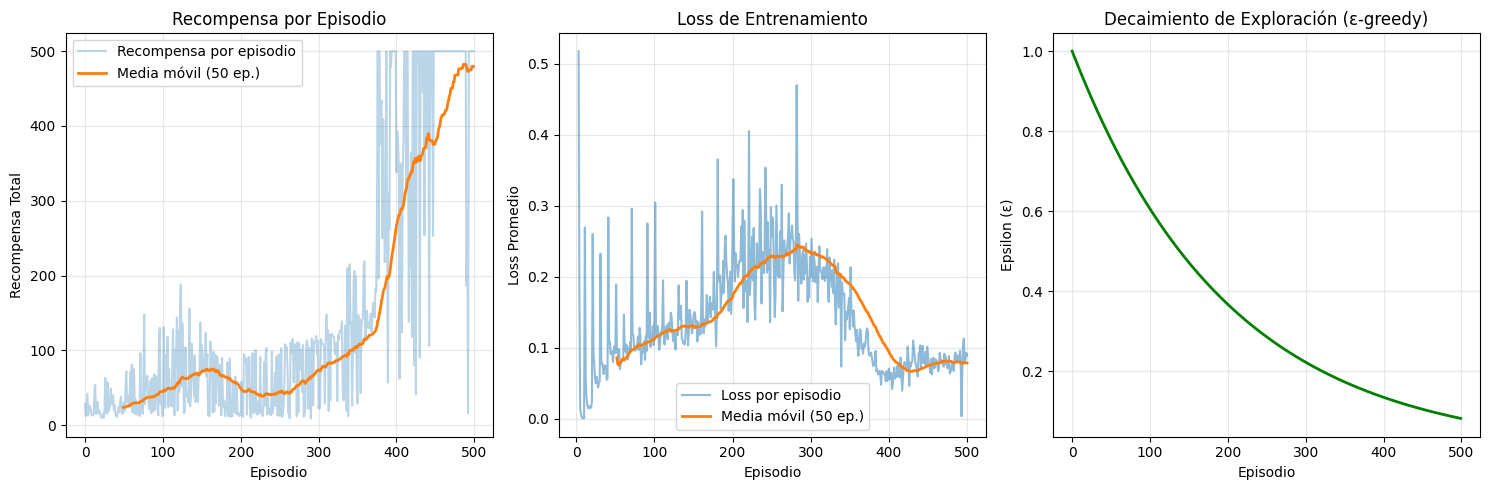


ESTADÍSTICAS DE ENTRENAMIENTO
Total de episodios:           500
Recompensa promedio total:    152.65
Recompensa promedio (últ.100):427.60
Recompensa máxima alcanzada:  500.00
Recompensa mínima alcanzada:  9.00
Loss promedio final (últ.50): 0.0788
Epsilon final:                0.0816


In [51]:
# Gráfica de recompensas por episodio
plt.figure(figsize=(15, 5))

# Subplot 1: Recompensa por episodio
plt.subplot(1, 3, 1)
plt.plot(episode_rewards, alpha=0.3, label='Recompensa por episodio')
# Media móvil para ver la tendencia
window_size = 50
if len(episode_rewards) >= window_size:
    moving_avg = np.convolve(episode_rewards, np.ones(window_size)/window_size, mode='valid')
    plt.plot(range(window_size-1, len(episode_rewards)), moving_avg, 
             linewidth=2, label=f'Media móvil ({window_size} ep.)')
plt.xlabel('Episodio')
plt.ylabel('Recompensa Total')
plt.title('Recompensa por Episodio')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Loss promedio por episodio
plt.subplot(1, 3, 2)
valid_losses = [l for l in episode_losses if not np.isnan(l)]
valid_episodes = [i for i, l in enumerate(episode_losses, 1) if not np.isnan(l)]
plt.plot(valid_episodes, valid_losses, alpha=0.5, label='Loss por episodio')
if len(valid_losses) >= window_size:
    loss_moving_avg = np.convolve(valid_losses, np.ones(window_size)/window_size, mode='valid')
    plt.plot(range(valid_episodes[window_size-1], valid_episodes[-1]+1), loss_moving_avg,
             linewidth=2, label=f'Media móvil ({window_size} ep.)')
plt.xlabel('Episodio')
plt.ylabel('Loss Promedio')
plt.title('Loss de Entrenamiento')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Epsilon decay
plt.subplot(1, 3, 3)
epsilons = [EPSILON * (EPSILON_DECAY ** i) for i in range(NUM_EPISODES)]
epsilons = [max(EPSILON_MIN, e) for e in epsilons]
plt.plot(epsilons, linewidth=2, color='green')
plt.xlabel('Episodio')
plt.ylabel('Epsilon (ε)')
plt.title('Decaimiento de Exploración (ε-greedy)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas finales
print(f"\n{'='*60}")
print("ESTADÍSTICAS DE ENTRENAMIENTO")
print(f"{'='*60}")
print(f"Total de episodios:           {NUM_EPISODES}")
print(f"Recompensa promedio total:    {np.mean(episode_rewards):.2f}")
print(f"Recompensa promedio (últ.100):{np.mean(episode_rewards[-100:]):.2f}")
print(f"Recompensa máxima alcanzada:  {np.max(episode_rewards):.2f}")
print(f"Recompensa mínima alcanzada:  {np.min(episode_rewards):.2f}")
print(f"Loss promedio final (últ.50): {np.nanmean(episode_losses[-50:]):.4f}")
print(f"Epsilon final:                {epsilon:.4f}")
print(f"{'='*60}")

### Evaluar el rendimiento del agente entrenado

Evaluando el agente entrenado en 100 episodios...
------------------------------------------------------------
Episodios completados: 20/100 | Promedio parcial: 500.00
Episodios completados: 40/100 | Promedio parcial: 500.00
Episodios completados: 60/100 | Promedio parcial: 500.00
Episodios completados: 80/100 | Promedio parcial: 500.00
Episodios completados: 100/100 | Promedio parcial: 500.00

RESULTADOS DE EVALUACIÓN
Episodios de evaluación:      100
Recompensa promedio:          500.00 ± 0.00
Recompensa mediana:           500.00
Recompensa máxima:            500.00
Recompensa mínima:            500.00
Tasa de éxito (≥195):         100.0%


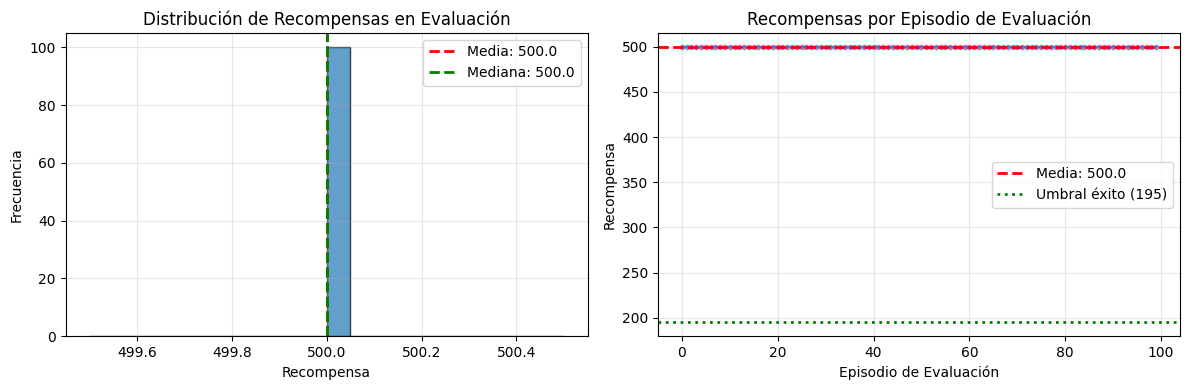


📊 ANÁLISIS DEL RENDIMIENTO:
✅ ¡EXCELENTE! El agente ha resuelto el problema (promedio ≥195)


In [ ]:
# Evaluación del agente entrenado en múltiples episodios
# Se usa política greedy pura (sin exploración)

eval_env = gym.make('CartPole-v1')
online_net.eval()  # Modo evaluación

NUM_EVAL_EPISODES = 100
eval_rewards = []

print(f"Evaluando el agente entrenado en {NUM_EVAL_EPISODES} episodios...")
print("-" * 60)

for eval_ep in range(NUM_EVAL_EPISODES):
    state, _ = eval_env.reset()
    done = False
    ep_reward = 0
    
    while not done:
        # Política greedy (sin exploración)
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            q_values = online_net(s)
            action = int(torch.argmax(q_values, dim=1).item())
        
        state, reward, terminated, truncated, _ = eval_env.step(action)
        done = terminated or truncated
        ep_reward += reward
    
    eval_rewards.append(ep_reward)
    
    if (eval_ep + 1) % 20 == 0:
        print(f"Episodios completados: {eval_ep+1}/{NUM_EVAL_EPISODES} | "
              f"Promedio parcial: {np.mean(eval_rewards):.2f}")

eval_env.close()

# Resultados de evaluación
print(f"\n{'='*60}")
print("RESULTADOS DE EVALUACIÓN")
print(f"{'='*60}")
print(f"Episodios de evaluación:      {NUM_EVAL_EPISODES}")
print(f"Recompensa promedio:          {np.mean(eval_rewards):.2f} ± {np.std(eval_rewards):.2f}")
print(f"Recompensa mediana:           {np.median(eval_rewards):.2f}")
print(f"Recompensa máxima:            {np.max(eval_rewards):.2f}")
print(f"Recompensa mínima:            {np.min(eval_rewards):.2f}")
print(f"Tasa de éxito (≥195):         {100 * np.sum(np.array(eval_rewards) >= 195) / NUM_EVAL_EPISODES:.1f}%")
print(f"{'='*60}")

# Visualización de resultados de evaluación
plt.figure(figsize=(12, 4))

# Histograma de recompensas
plt.subplot(1, 2, 1)
plt.hist(eval_rewards, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(np.mean(eval_rewards), color='red', linestyle='--', linewidth=2, label=f'Media: {np.mean(eval_rewards):.1f}')
plt.axvline(np.median(eval_rewards), color='green', linestyle='--', linewidth=2, label=f'Mediana: {np.median(eval_rewards):.1f}')
plt.xlabel('Recompensa')
plt.ylabel('Frecuencia')
plt.title('Distribución de Recompensas en Evaluación')
plt.legend()
plt.grid(True, alpha=0.3)

# Serie temporal de recompensas de evaluación
plt.subplot(1, 2, 2)
plt.plot(eval_rewards, marker='o', markersize=3, alpha=0.6)
plt.axhline(np.mean(eval_rewards), color='red', linestyle='--', linewidth=2, label=f'Media: {np.mean(eval_rewards):.1f}')
plt.axhline(195, color='green', linestyle=':', linewidth=2, label='Umbral éxito (195)')
plt.xlabel('Episodio de Evaluación')
plt.ylabel('Recompensa')
plt.title('Recompensas por Episodio de Evaluación')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretación del rendimiento
print("\n📊 ANÁLISIS DEL RENDIMIENTO:")
avg_reward = np.mean(eval_rewards)
if avg_reward >= 195:
    print("✅ ¡EXCELENTE! El agente ha resuelto el problema (promedio ≥195)")
elif avg_reward >= 150:
    print("✓ BUENO: El agente tiene un buen rendimiento, pero puede mejorar")
elif avg_reward >= 100:
    print("⚠ MODERADO: El agente ha aprendido, pero necesita más entrenamiento")
else:
    print("❌ INSUFICIENTE: El agente necesita ajuste de hiperparámetros o más entrenamiento")